## 1. Configuration initiale et chargement des données

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import xml.etree.ElementTree as ET
import random
import cv2
from tqdm import tqdm
import scipy.io
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# Configuration des plots pour des graphiques professionnels
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.titlesize': 16
})

# Palette de couleurs professionnelle
colors = ['#2E86C1', '#28B463', '#F39C12', '#E74C3C', '#8E44AD', '#17A2B8', '#FFC107']
sns.set_palette(colors)

# Seed pour la reproductibilité
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
from concurrent.futures import ThreadPoolExecutor

La base de données est organisée comme suit : un dossier data qui contient trois sous dossiers :
* Images : il contient des sous dossiers correspondant à chaque race. Pour chaque race le dossier contient les images des chiens correspondants numérotés.
* Annotation : il contient aussi des sous dossiers correspondant à chaque race. Cette fois-ci pour chaque race, on a pour chien numéro de chien des images, une annotation qui précise les caractéristique de l'images ainsi que le bounding box de la localisation précise du chien sur l'image.
* Lists : il contient 3 fichiers. file_list contient des information sur les chemin relatifs de chaque images desquelles on peut aisement deduire ceux des annotations. De même on a les fichiers train_list et test_list qui précisent le découpage pour les dnnées d'entrainement et de test

In [ ]:

# Définir les chemins vers les données
current_dir = Path('/content/drive/MyDrive/ml_dogs/project/')
project_path = Path('/content/drive/MyDrive/ml_dogs/project/')
data_path = project_path / "data"
images_dir = data_path / "Images"
annotations_dir = data_path / "Annotation"
lists_dir = data_path / "lists"

# Vérifier les répertoires
if not all([images_dir.exists(), annotations_dir.exists(), lists_dir.exists()]):
    print("ATTENTION: Certains répertoires du dataset n'existent pas.")
else:
    print(f"Répertoire d'images: {images_dir}")
    print(f"Répertoire d'annotations: {annotations_dir}")
    print(f"Répertoire de listes: {lists_dir}")


Répertoire d'images: /content/drive/MyDrive/ml_dogs/project/data/Images
Répertoire d'annotations: /content/drive/MyDrive/ml_dogs/project/data/Annotation
Répertoire de listes: /content/drive/MyDrive/ml_dogs/project/data/lists


In [ ]:
# Charger le fichier file_list.mat
file_list_path = lists_dir / "file_list.mat"
file_data = scipy.io.loadmat(file_list_path)

# Extraire les informations
file_list = file_data['file_list'].flatten()
annotation_list = file_data['annotation_list'].flatten()
labels = file_data['labels'].flatten()

print(f"Nombre total d'images: {len(file_list)}")
print(f"Nombre total d'annotations: {len(annotation_list)}")
print(f"Nombre de classes uniques: {len(np.unique(labels))}")

Nombre total d'images: 20580
Nombre total d'annotations: 20580
Nombre de classes uniques: 120


## 2. Analyse et visualisation des classes

On constate qu'on n'a pas le même nombre d'images de chiens par race. Alors que la race minoritaire (redbone) contient 148 images, la race majoritaire (Maltese dog) en contient 252. 75% des races ayant moins de 186 images et la médiane se situant autour de 159 images, on peut déduire qu'il y'a que très peu de races qui ont un nombre d'images s'écartant des autres. De plus le ratio entre le max/min est de 1.7, acceptable. Cette analyse est confirmée par le second graphique ci-après. Le déséquilibre observé est donc acceptable. Les résultats de la modélisation permettrons d'y revenir au besoin.

In [ ]:
# Extraire les noms de races à partir des chemins d'images
breeds_info = []
for i, img_path in enumerate(file_list):
    img_path_str = img_path[0]
    breed_name = img_path_str.split('/')[0]
    breeds_info.append({
        'breed': breed_name,
        'label': labels[i],
        'image_path': img_path_str
    })

df_breeds = pd.DataFrame(breeds_info)

# Analyser la distribution des classes
class_distribution = df_breeds['breed'].value_counts().reset_index()
class_distribution.columns = ['breed', 'count']
class_distribution['breed_clean'] = class_distribution['breed'].str.replace('-', ' ').str.replace('_', ' ')

print("Statistiques de distribution des classes:")
print(class_distribution['count'].describe())


# Afficher les statistiques de distribution
print("\nRaces avec le plus grand nombre d'images:")
print(class_distribution[['breed_clean', 'count']].head())
print("\nRaces avec le moins d'images:")
print(class_distribution[['breed_clean', 'count']].tail())



Statistiques de distribution des classes:
count    120.000000
mean     171.500000
std       23.220898
min      148.000000
25%      152.750000
50%      159.500000
75%      186.250000
max      252.000000
Name: count, dtype: float64

Races avec le plus grand nombre d'images:
                      breed_clean  count
0           n02085936 Maltese dog    252
1          n02088094 Afghan hound    239
2    n02092002 Scottish deerhound    232
3            n02112018 Pomeranian    219
4  n02107683 Bernese mountain dog    218

Races avec le moins d'images:
                 breed_clean  count
115    n02105056 groenendael    150
116  n02110627 affenpinscher    150
117          n02115913 dhole    150
118       n02086079 Pekinese    149
119        n02090379 redbone    148


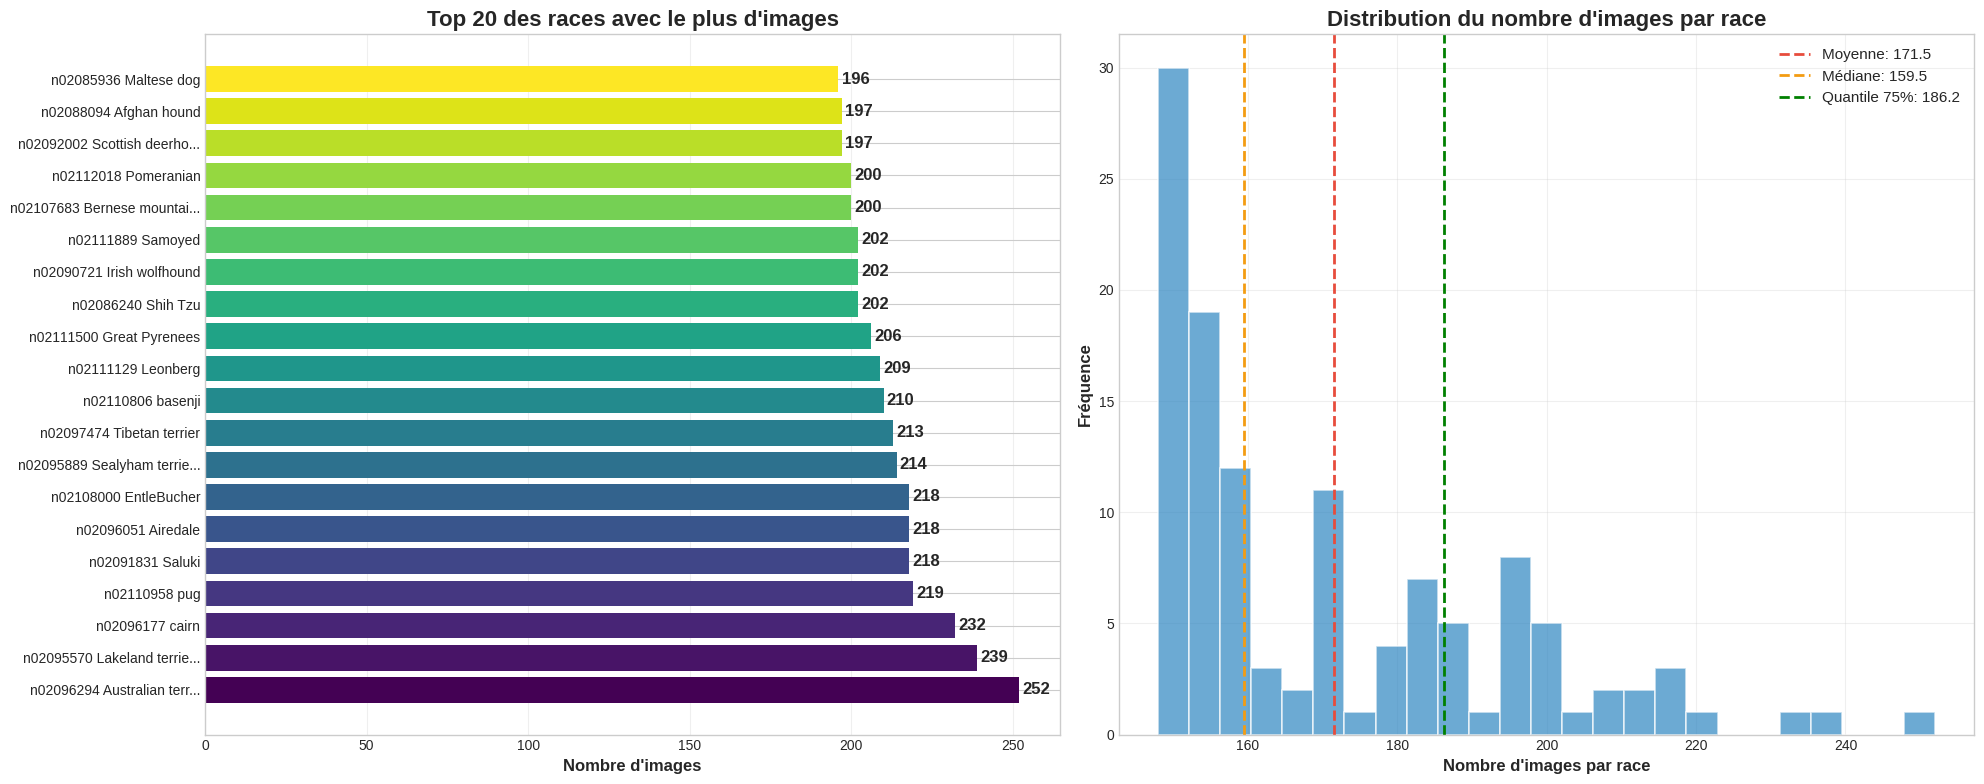

In [ ]:
# Graphique 1: Distribution des classes (Top 20)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Top 20 des races
top_20 = class_distribution.head(20)
bars = ax1.barh(range(len(top_20)), top_20['count'],
                color=plt.cm.viridis(np.linspace(0, 1, len(top_20))))
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels([name[:25] + '...' if len(name) > 25 else name
                     for name in reversed(top_20['breed_clean'])])
ax1.set_xlabel('Nombre d\'images', fontweight='bold')
ax1.set_title('Top 20 des races avec le plus d\'images', fontweight='bold', fontsize=16)
ax1.grid(axis='x', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontweight='bold')


# Histogramme de distribution
ax2.hist(class_distribution['count'], bins=25, color='#2E86C1', alpha=0.7,
         edgecolor='white', linewidth=1.2)
ax2.axvline(class_distribution['count'].mean(), color='#E74C3C', linestyle='--',
            linewidth=2, label=f'Moyenne: {class_distribution["count"].mean():.1f}')
ax2.axvline(class_distribution['count'].median(), color='#F39C12', linestyle='--',
            linewidth=2, label=f'Médiane: {class_distribution["count"].median():.1f}')
ax2.axvline(class_distribution['count'].quantile(0.75), color='green', linestyle='--',
            linewidth=2, label=f'Quantile 75%: {class_distribution["count"].quantile(0.75):.1f}')

ax2.set_xlabel('Nombre d\'images par race', fontweight='bold')
ax2.set_ylabel('Fréquence', fontweight='bold')
ax2.set_title('Distribution du nombre d\'images par race', fontweight='bold', fontsize=16)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Analyse des dimensions d'images et bounding boxes

Les images ont différentes dimensions. La dimensions des images originales tourne autour de (3, 455, 450) (couche, largeur, hauteur) avec une très grande variabilité et des ratio largeur hauteur tres dispersés (concentrés entre 0.5 et 2. Cependant avec les bbox, les dimensions reviennent à environ (3 , 300, 325) toujours avec une grande variabilité mais un ratio concentré autour de 1. Par ailleurs la couverture des bbox par rapport aux images de base est d'environ 54.2%. Donc en moyenne il y'a une grande partie de l'image renseigne sur l'environnement du chien plutôt que le chien lui même.  

Par la suite pour la modélisation nous utiliserons les images croppées pour rduire le bruit dû à l'environnement. Aussi les images croppés serot redimensonnées à (3, 256, 256).  

In [ ]:
def parse_annotation_fast(annotation_path):
    """Parse annotation XML rapidement"""
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    size = root.find('size')
    obj = root.find('object')
    bndbox = obj.find('bndbox')

    return {
        'width': int(size.find('width').text),
        'height': int(size.find('height').text),
        'xmin': int(bndbox.find('xmin').text),
        'ymin': int(bndbox.find('ymin').text),
        'xmax': int(bndbox.find('xmax').text),
        'ymax': int(bndbox.find('ymax').text)
    }

In [ ]:
def parse_annotations_parallel(annotation_list, annotations_dir, max_workers=128):
    """Parse toutes les annotations en parallèle"""
    print(f"Parsing de {len(annotation_list)} annotations en parallèle...")

    def parse_single(i):
        annotation_path = annotations_dir / annotation_list[i][0]
        data = parse_annotation_fast(annotation_path)
        if data is None:
            return None

        bbox_width = data['xmax'] - data['xmin']
        bbox_height = data['ymax'] - data['ymin']
        bbox_area = bbox_width * bbox_height
        image_area = data['width'] * data['height']
        bbox_coverage = bbox_area / image_area if image_area > 0 else 0

        return {
            'image_idx': i,
            'img_width': data['width'],
            'img_height': data['height'],
            'img_aspect_ratio': data['width'] / data['height'],
            'bbox_width': bbox_width,
            'bbox_height': bbox_height,
            'bbox_area': bbox_area,
            'bbox_coverage': bbox_coverage,
            'bbox_aspect_ratio': bbox_width / bbox_height if bbox_height > 0 else 0,
            'xmin': data['xmin'], 'ymin': data['ymin'],
            'xmax': data['xmax'], 'ymax': data['ymax']
        }

    # Traitement en parallèle
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(
            executor.map(parse_single, range(len(annotation_list))),
            total=len(annotation_list),
            desc="Parsing annotations"
        ))

    # Filtrer les résultats valides
    valid_results = [r for r in results if r is not None]
    return pd.DataFrame(valid_results)

# Utiliser la fonction optimisée
df_annotations = parse_annotations_parallel(annotation_list, annotations_dir)

Parsing de 20580 annotations en parallèle...


Parsing annotations: 100%|██████████| 20580/20580 [02:15<00:00, 151.73it/s]


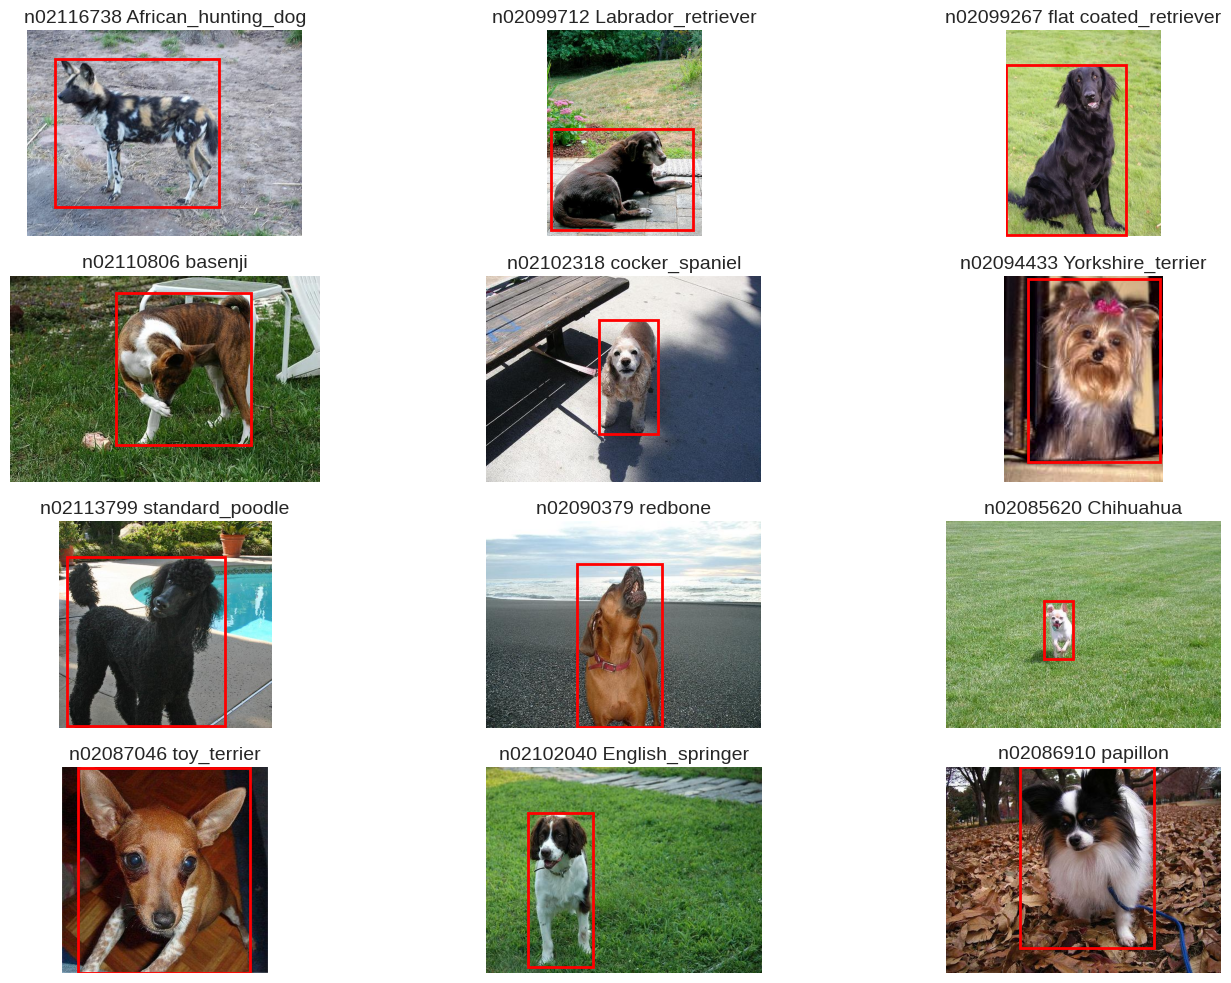

In [ ]:
# Visualisation d'exemples d'images avec bounding boxes
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Sélectionner 6 images aléatoirement
n_samples = 12
sample_indices = np.random.choice(len(file_list), n_samples, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    # Charger l'image
    img_path = images_dir / file_list[idx][0]
    img = Image.open(img_path)

    # Récupérer les coordonnées du bounding box
    bbox_data = df_annotations[df_annotations['image_idx'] == idx].iloc[0]

    # Afficher l'image
    axes[i].imshow(img)

    # Créer le rectangle pour le bounding box
    rect = patches.Rectangle(
        (bbox_data['xmin'], bbox_data['ymin']),
        bbox_data['bbox_width'],
        bbox_data['bbox_height'],
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    axes[i].add_patch(rect)

    # Titre avec le nom de la race
    breed_name = file_list[idx][0].split('/')[0].replace('-', ' ')
    axes[i].set_title(f'{breed_name}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

<ipython-input-23-3792326873>:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 2].boxplot(box_data, labels=['Largeur', 'Hauteur'], patch_artist=True)
<ipython-input-23-3792326873>:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 2].boxplot(box_data_bbox, labels=['Largeur', 'Hauteur'], patch_artist=True)


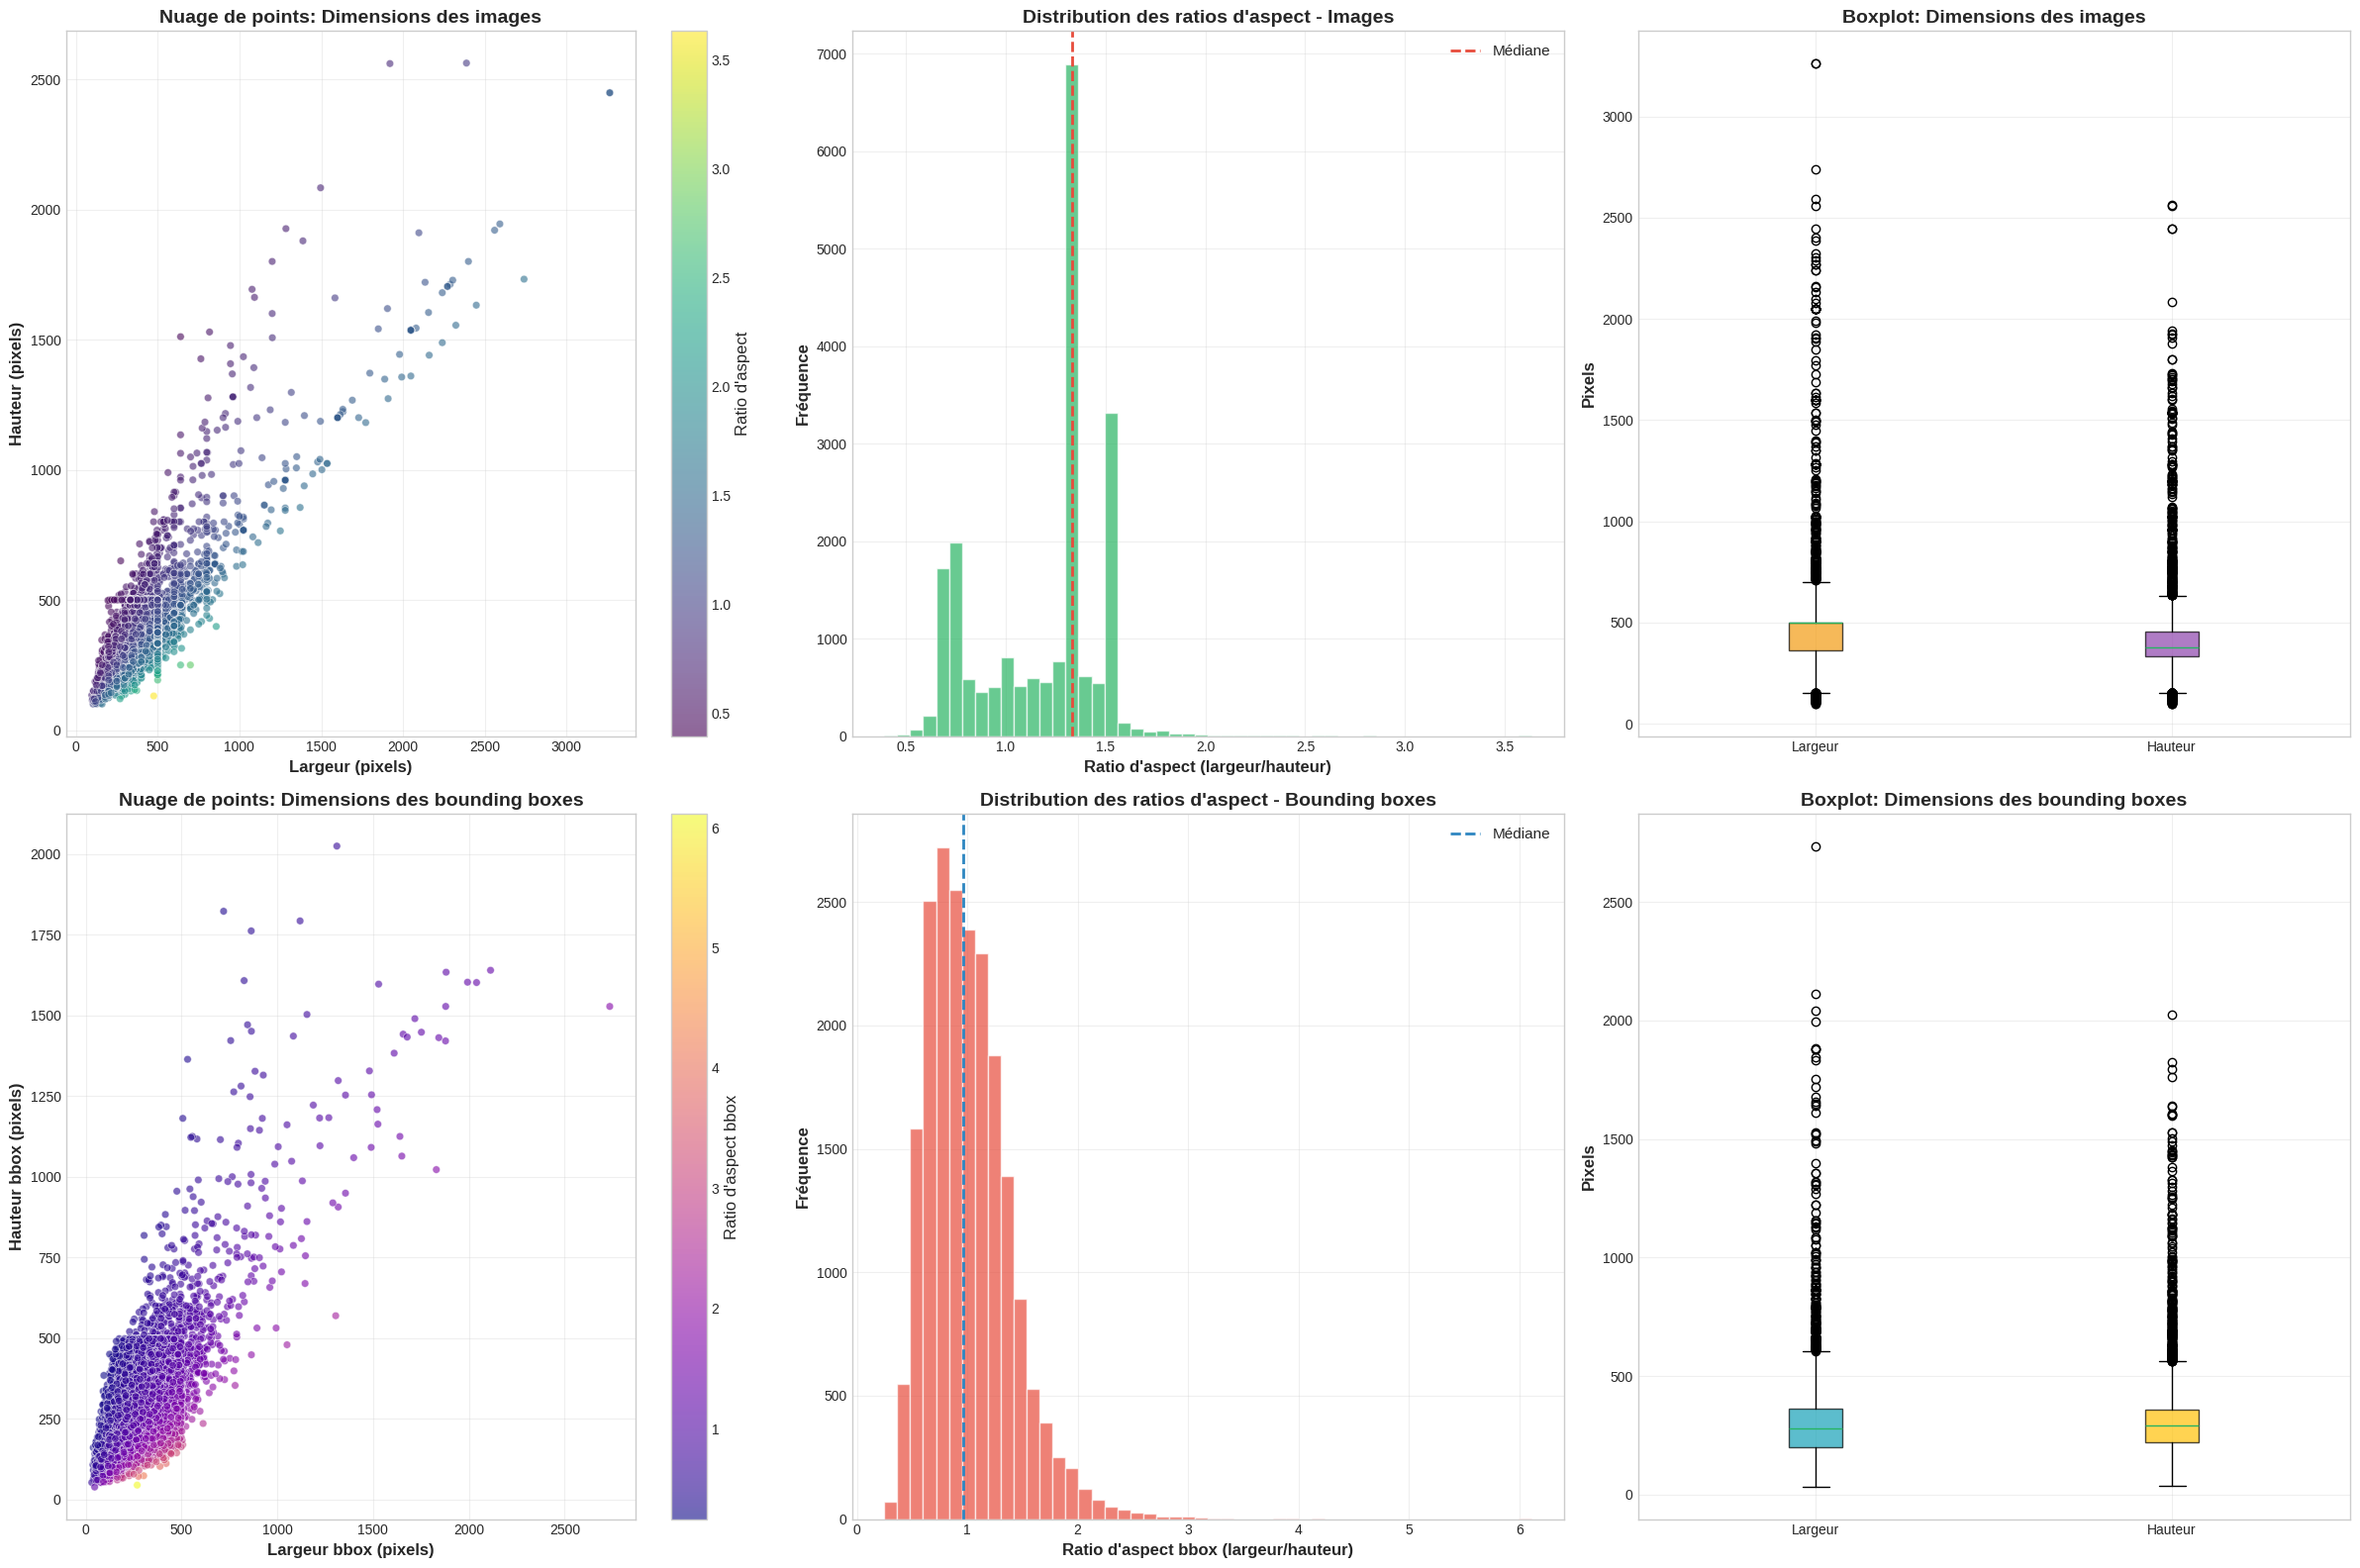

In [ ]:
# Graphiques pour l'analyse des dimensions (6 graphiques)
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# 1. Nuage de points dimensions images (largeur x hauteur)
scatter = axes[0, 0].scatter(df_annotations['img_width'], df_annotations['img_height'],
                           c=df_annotations['img_aspect_ratio'], cmap='viridis',
                           alpha=0.6, s=30, edgecolors='white', linewidth=0.5)
axes[0, 0].set_xlabel('Largeur (pixels)', fontweight='bold')
axes[0, 0].set_ylabel('Hauteur (pixels)', fontweight='bold')
axes[0, 0].set_title('Nuage de points: Dimensions des images', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 0], label='Ratio d\'aspect')

# 2. Distribution des ratios d'aspect des images
axes[0, 1].hist(df_annotations['img_aspect_ratio'], bins=50, color='#28B463',
                alpha=0.7, edgecolor='white')
axes[0, 1].axvline(df_annotations['img_aspect_ratio'].median(), color='#E74C3C',
                   linestyle='--', linewidth=2, label='Médiane')
axes[0, 1].set_xlabel('Ratio d\'aspect (largeur/hauteur)', fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontweight='bold')
axes[0, 1].set_title('Distribution des ratios d\'aspect - Images', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Boxplot des dimensions des images
box_data = [df_annotations['img_width'], df_annotations['img_height']]
bp = axes[0, 2].boxplot(box_data, labels=['Largeur', 'Hauteur'], patch_artist=True)
colors_box = ['#F39C12', '#8E44AD']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 2].set_ylabel('Pixels', fontweight='bold')
axes[0, 2].set_title('Boxplot: Dimensions des images', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# 4. Nuage de points dimensions bounding boxes (largeur x hauteur)
scatter2 = axes[1, 0].scatter(df_annotations['bbox_width'], df_annotations['bbox_height'],
                            c=df_annotations['bbox_aspect_ratio'], cmap='plasma',
                            alpha=0.6, s=30, edgecolors='white', linewidth=0.5)
axes[1, 0].set_xlabel('Largeur bbox (pixels)', fontweight='bold')
axes[1, 0].set_ylabel('Hauteur bbox (pixels)', fontweight='bold')
axes[1, 0].set_title('Nuage de points: Dimensions des bounding boxes', fontweight='bold')
axes[1, 0].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1, 0], label='Ratio d\'aspect bbox')

# 5. Distribution des ratios d'aspect des bounding boxes
axes[1, 1].hist(df_annotations['bbox_aspect_ratio'], bins=50, color='#E74C3C',
                alpha=0.7, edgecolor='white')
axes[1, 1].axvline(df_annotations['bbox_aspect_ratio'].median(), color='#2E86C1',
                   linestyle='--', linewidth=2, label='Médiane')
axes[1, 1].set_xlabel('Ratio d\'aspect bbox (largeur/hauteur)', fontweight='bold')
axes[1, 1].set_ylabel('Fréquence', fontweight='bold')
axes[1, 1].set_title('Distribution des ratios d\'aspect - Bounding boxes', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Boxplot des dimensions des bounding boxes
box_data_bbox = [df_annotations['bbox_width'], df_annotations['bbox_height']]
bp2 = axes[1, 2].boxplot(box_data_bbox, labels=['Largeur', 'Hauteur'], patch_artist=True)
colors_box2 = ['#17A2B8', '#FFC107']
for patch, color in zip(bp2['boxes'], colors_box2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 2].set_ylabel('Pixels', fontweight='bold')
axes[1, 2].set_title('Boxplot: Dimensions des bounding boxes', fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

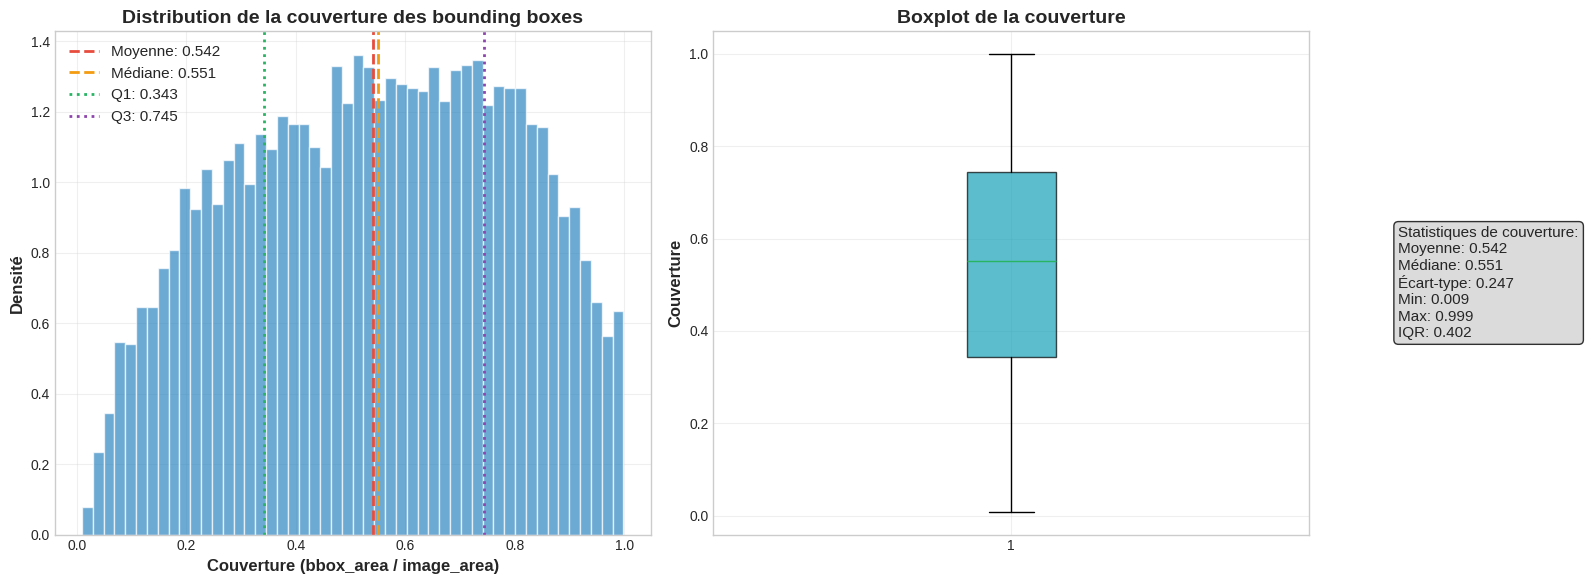

=== STATISTIQUES DE COUVERTURE DES BOUNDING BOXES ===
Moyenne: 0.5416
Médiane: 0.5510
Écart-type: 0.2468
Min: 0.0089
Max: 0.9988
Q1: 0.3426
Q3: 0.7446

Interprétation:
- 11662 images (56.7%) ont une couverture > 50%
- 6369 images (30.9%) ont une couverture > 70%
- 4218 images (20.5%) ont une couverture < 30%


In [ ]:
# Analyse de la couverture des bounding boxes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Calculer les statistiques
coverage_stats = {
    'Moyenne': df_annotations['bbox_coverage'].mean(),
    'Médiane': df_annotations['bbox_coverage'].median(),
    'Écart-type': df_annotations['bbox_coverage'].std(),
    'Min': df_annotations['bbox_coverage'].min(),
    'Max': df_annotations['bbox_coverage'].max(),
    'Q1': df_annotations['bbox_coverage'].quantile(0.25),
    'Q3': df_annotations['bbox_coverage'].quantile(0.75)
}

# 1. Histogramme de la couverture avec statistiques
ax1.hist(df_annotations['bbox_coverage'], bins=50, color='#2E86C1',
         alpha=0.7, edgecolor='white', density=True)

# Ajouter les lignes de statistiques
ax1.axvline(coverage_stats['Moyenne'], color='#E74C3C', linestyle='--',
           linewidth=2, label=f'Moyenne: {coverage_stats["Moyenne"]:.3f}')
ax1.axvline(coverage_stats['Médiane'], color='#F39C12', linestyle='--',
           linewidth=2, label=f'Médiane: {coverage_stats["Médiane"]:.3f}')
ax1.axvline(coverage_stats['Q1'], color='#28B463', linestyle=':',
           linewidth=2, label=f'Q1: {coverage_stats["Q1"]:.3f}')
ax1.axvline(coverage_stats['Q3'], color='#8E44AD', linestyle=':',
           linewidth=2, label=f'Q3: {coverage_stats["Q3"]:.3f}')

ax1.set_xlabel('Couverture (bbox_area / image_area)', fontweight='bold')
ax1.set_ylabel('Densité', fontweight='bold')
ax1.set_title('Distribution de la couverture des bounding boxes', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Boxplot avec points aberrants
bp = ax2.boxplot(df_annotations['bbox_coverage'], patch_artist=True,
                 showfliers=True, flierprops=dict(marker='o', markersize=4, alpha=0.5))
bp['boxes'][0].set_facecolor('#17A2B8')
bp['boxes'][0].set_alpha(0.7)

ax2.set_ylabel('Couverture', fontweight='bold')
ax2.set_title('Boxplot de la couverture', fontweight='bold')
ax2.grid(alpha=0.3)

# Ajouter du texte avec les statistiques
stats_text = f"""Statistiques de couverture:
Moyenne: {coverage_stats['Moyenne']:.3f}
Médiane: {coverage_stats['Médiane']:.3f}
Écart-type: {coverage_stats['Écart-type']:.3f}
Min: {coverage_stats['Min']:.3f}
Max: {coverage_stats['Max']:.3f}
IQR: {coverage_stats['Q3'] - coverage_stats['Q1']:.3f}"""

ax2.text(1.15, 0.5, stats_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

# Afficher les statistiques dans la console
print("=== STATISTIQUES DE COUVERTURE DES BOUNDING BOXES ===")
for stat, value in coverage_stats.items():
    print(f"{stat}: {value:.4f}")

print(f"\nInterprétation:")
print(f"- {(df_annotations['bbox_coverage'] > 0.5).sum()} images ({(df_annotations['bbox_coverage'] > 0.5).mean()*100:.1f}%) ont une couverture > 50%")
print(f"- {(df_annotations['bbox_coverage'] > 0.7).sum()} images ({(df_annotations['bbox_coverage'] > 0.7).mean()*100:.1f}%) ont une couverture > 70%")
print(f"- {(df_annotations['bbox_coverage'] < 0.3).sum()} images ({(df_annotations['bbox_coverage'] < 0.3).mean()*100:.1f}%) ont une couverture < 30%")

## 4. Analyse des pixels

On constate que la luminosité et le constraste vairent considérablement entre les races. Aussi en visulaisant les images on constate que ces deux parametres sont aussi varaibles au sein d'une même race. Une unifomisation permettra donc d'homogéniser les races tout en permettrant au modèle de bien apprendre.   
la visualisation des canaux RGB montre que le rouge domine les autres couleurs et il y'a aussi présence des outliers. les valeurs seront donc standardisés et au besoin normalisé pour permettre une rapide convergence des modeles.

Analyse des races: 100%|██████████| 10/10 [06:23<00:00, 38.37s/it]
<ipython-input-29-4034848897>:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,1].boxplot(rgb_data, labels=['Rouge', 'Vert', 'Bleu'], patch_artist=True)


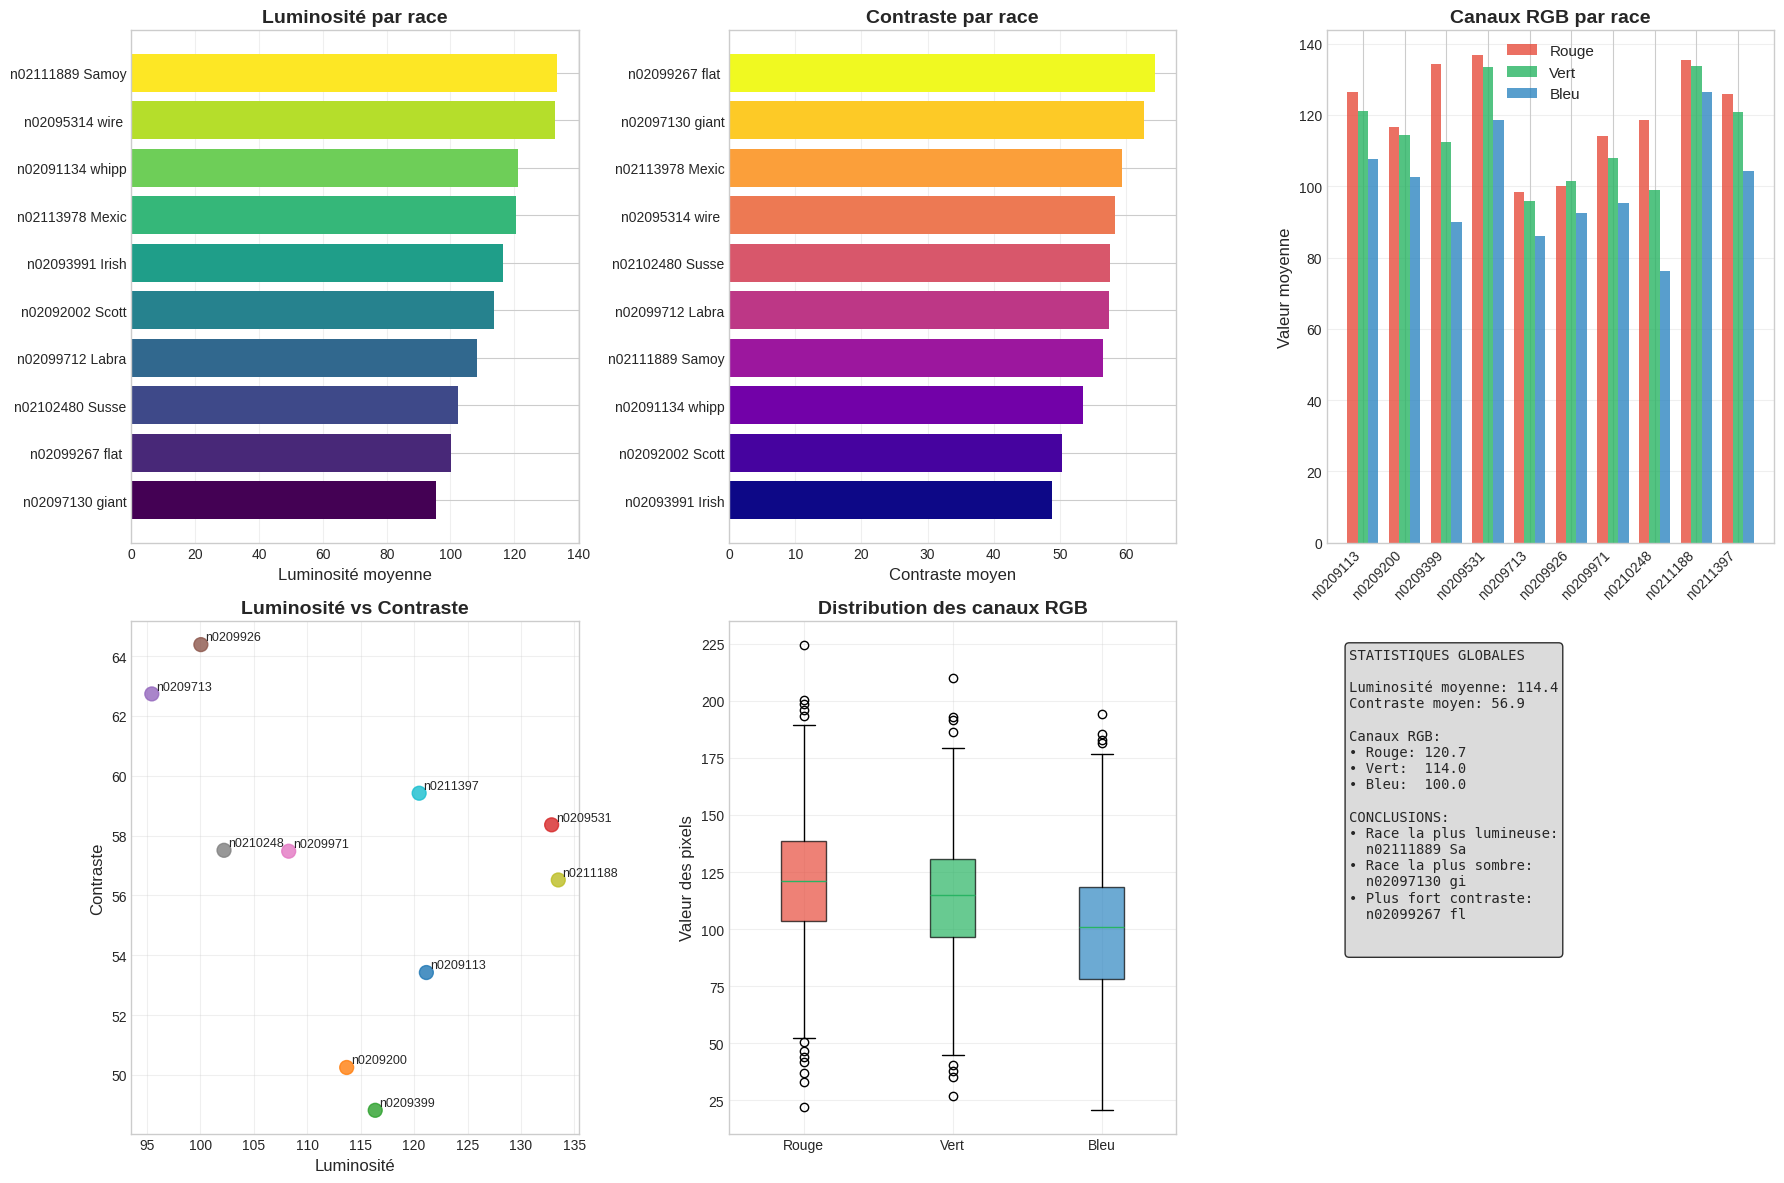

Analyse terminée sur 500 images croppées de 10 races


In [29]:

def crop_and_analyze_pixels(img_path, bbox_data):
    """Cropper une image et analyser ses pixels"""
    img = Image.open(img_path)
    img_array = np.array(img)

    # Cropper selon le bbox
    xmin, ymin = int(bbox_data['xmin']), int(bbox_data['ymin'])
    xmax, ymax = int(bbox_data['xmax']), int(bbox_data['ymax'])
    cropped = img_array[ymin:ymax, xmin:xmax]

    # Analyser les pixels
    if len(cropped.shape) == 3:
        # Luminosité (formule standard)
        luminosity = 0.299 * cropped[:,:,0] + 0.587 * cropped[:,:,1] + 0.114 * cropped[:,:,2]
        r, g, b = cropped[:,:,0], cropped[:,:,1], cropped[:,:,2]
    else:
        luminosity = r = g = b = cropped

    return {
        'brightness': np.mean(luminosity),
        'contrast': np.std(luminosity),
        'r_mean': np.mean(r),
        'g_mean': np.mean(g),
        'b_mean': np.mean(b)
    }

# Sélectionner 10 races aléatoirement
np.random.seed(100)
selected_breeds = np.random.choice(df_breeds['breed'].unique(), 10, replace=False)

# Analyser 12 images par race
results = []
for breed in tqdm(selected_breeds, desc="Analyse des races"):
    breed_data = df_breeds[df_breeds['breed'] == breed]
    sample_indices = np.random.choice(breed_data.index, min(50, len(breed_data)), replace=False)

    for idx in sample_indices:
        try:
            img_info = breed_data.loc[idx]
            img_idx = df_breeds.index.get_loc(idx)
            img_path = images_dir / img_info['image_path']
            bbox_data = df_annotations[df_annotations['image_idx'] == img_idx].iloc[0]

            pixel_stats = crop_and_analyze_pixels(img_path, bbox_data)
            pixel_stats['breed'] = breed.replace('-', ' ').replace('_', ' ')
            results.append(pixel_stats)
        except:
            continue

df_pixels = pd.DataFrame(results)

# Créer les visualisations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Luminosité par race
brightness_stats = df_pixels.groupby('breed')['brightness'].mean().sort_values()
axes[0,0].barh(range(len(brightness_stats)), brightness_stats.values,
               color=plt.cm.viridis(np.linspace(0, 1, len(brightness_stats))))
axes[0,0].set_yticks(range(len(brightness_stats)))
axes[0,0].set_yticklabels([name[:15] for name in brightness_stats.index])
axes[0,0].set_xlabel('Luminosité moyenne')
axes[0,0].set_title('Luminosité par race', fontweight='bold')
axes[0,0].grid(axis='x', alpha=0.3)

# 2. Contraste par race
contrast_stats = df_pixels.groupby('breed')['contrast'].mean().sort_values()
axes[0,1].barh(range(len(contrast_stats)), contrast_stats.values,
               color=plt.cm.plasma(np.linspace(0, 1, len(contrast_stats))))
axes[0,1].set_yticks(range(len(contrast_stats)))
axes[0,1].set_yticklabels([name[:15] for name in contrast_stats.index])
axes[0,1].set_xlabel('Contraste moyen')
axes[0,1].set_title('Contraste par race', fontweight='bold')
axes[0,1].grid(axis='x', alpha=0.3)

# 3. Canaux RGB
rgb_means = df_pixels.groupby('breed')[['r_mean', 'g_mean', 'b_mean']].mean()
x = np.arange(len(rgb_means))
width = 0.25

axes[0,2].bar(x - width, rgb_means['r_mean'], width, label='Rouge', color='#E74C3C', alpha=0.8)
axes[0,2].bar(x, rgb_means['g_mean'], width, label='Vert', color='#28B463', alpha=0.8)
axes[0,2].bar(x + width, rgb_means['b_mean'], width, label='Bleu', color='#2E86C1', alpha=0.8)

axes[0,2].set_xticks(x)
axes[0,2].set_xticklabels([name[:8] for name in rgb_means.index], rotation=45, ha='right')
axes[0,2].set_ylabel('Valeur moyenne')
axes[0,2].set_title('Canaux RGB par race', fontweight='bold')
axes[0,2].legend()
axes[0,2].grid(axis='y', alpha=0.3)

# 4. Relation luminosité vs contraste
breed_summary = df_pixels.groupby('breed').agg({'brightness': 'mean', 'contrast': 'mean'}).reset_index()
scatter = axes[1,0].scatter(breed_summary['brightness'], breed_summary['contrast'],
                           c=range(len(breed_summary)), cmap='tab10', s=100, alpha=0.8)
for _, row in breed_summary.iterrows():
    axes[1,0].annotate(row['breed'][:8], (row['brightness'], row['contrast']),
                      xytext=(3, 3), textcoords='offset points', fontsize=9)
axes[1,0].set_xlabel('Luminosité')
axes[1,0].set_ylabel('Contraste')
axes[1,0].set_title('Luminosité vs Contraste', fontweight='bold')
axes[1,0].grid(alpha=0.3)

# 5. Distribution RGB globale
rgb_data = [df_pixels['r_mean'], df_pixels['g_mean'], df_pixels['b_mean']]
bp = axes[1,1].boxplot(rgb_data, labels=['Rouge', 'Vert', 'Bleu'], patch_artist=True)
colors = ['#E74C3C', '#28B463', '#2E86C1']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,1].set_ylabel('Valeur des pixels')
axes[1,1].set_title('Distribution des canaux RGB', fontweight='bold')
axes[1,1].grid(alpha=0.3)

# 6. Statistiques et conclusions
axes[1,2].axis('off')
stats_text = f"""STATISTIQUES GLOBALES

Luminosité moyenne: {df_pixels['brightness'].mean():.1f}
Contraste moyen: {df_pixels['contrast'].mean():.1f}

Canaux RGB:
• Rouge: {df_pixels['r_mean'].mean():.1f}
• Vert:  {df_pixels['g_mean'].mean():.1f}
• Bleu:  {df_pixels['b_mean'].mean():.1f}

CONCLUSIONS:
• Race la plus lumineuse:
  {brightness_stats.index[-1][:12]}
• Race la plus sombre:
  {brightness_stats.index[0][:12]}
• Plus fort contraste:
  {contrast_stats.index[-1][:12]}

"""

axes[1,2].text(0.05, 0.95, stats_text, transform=axes[1,2].transAxes,
               fontsize=10, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Analyse terminée sur {len(df_pixels)} images croppées de {len(selected_breeds)} races")